In [1]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile, os
from pathlib import Path

print("🔍 Dosya aranıyor...")
search_results = !find /content/drive/MyDrive -name "MultiRes_ConfocFluo_HumanDentin.zip"

if search_results:
    ZIP_PATH = search_results[0]
    print(f"✅ Bulundu: {ZIP_PATH}")
else:
    ZIP_PATH = "/content/drive/MyDrive/MultiRes_ConfocFluo_HumanDentin.zip"
    print("❌ Bulunamadı!")

EXTRACT_PATH = "/content/dataset"
check = Path(EXTRACT_PATH) / "MultiRes_ConfocFluo_HumanDentin/ImagePatches128/Classified"

if check.exists():
    print("✅ Dataset zaten açık!")
else:
    print("📦 Açılıyor (~5 dk)...")
    os.makedirs(EXTRACT_PATH, exist_ok=True)
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        dosyalar = [f for f in z.namelist() if 'ImagePatches128' in f]
        toplam = len(dosyalar)
        for i, d in enumerate(dosyalar):
            z.extract(d, EXTRACT_PATH)
            if i % 10000 == 0:
                print(f"  {i:,}/{toplam:,} ({i/toplam*100:.0f}%)")
    print("✅ Açıldı!")

for s in ["tubules","branches","both"]:
    print(f"  {s}/HR: {len(list((check/s/'HR').glob('*.tif'))):,}")

Mounted at /content/drive
🔍 Dosya aranıyor...
✅ Bulundu: /content/drive/MyDrive/MultiRes_ConfocFluo_HumanDentin.zip
📦 Açılıyor (~5 dk)...
  0/361,873 (0%)
  10,000/361,873 (3%)
  20,000/361,873 (6%)
  30,000/361,873 (8%)
  40,000/361,873 (11%)
  50,000/361,873 (14%)
  60,000/361,873 (17%)
  70,000/361,873 (19%)
  80,000/361,873 (22%)
  90,000/361,873 (25%)
  100,000/361,873 (28%)
  110,000/361,873 (30%)
  120,000/361,873 (33%)
  130,000/361,873 (36%)
  140,000/361,873 (39%)
  150,000/361,873 (41%)
  160,000/361,873 (44%)
  170,000/361,873 (47%)
  180,000/361,873 (50%)
  190,000/361,873 (53%)
  200,000/361,873 (55%)
  210,000/361,873 (58%)
  220,000/361,873 (61%)
  230,000/361,873 (64%)
  240,000/361,873 (66%)
  250,000/361,873 (69%)
  260,000/361,873 (72%)
  270,000/361,873 (75%)
  280,000/361,873 (77%)
  290,000/361,873 (80%)
  300,000/361,873 (83%)
  310,000/361,873 (86%)
  320,000/361,873 (88%)
  330,000/361,873 (91%)
  340,000/361,873 (94%)
  350,000/361,873 (97%)
  360,000/361,873

In [2]:
import torch, warnings
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import tifffile, seaborn as sns
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
warnings.filterwarnings('ignore')

DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE    = 32
NUM_EPOCHS    = 20
RANDOM_SEED   = 42
torch.manual_seed(RANDOM_SEED)

PATCHES_ROOT  = Path("/content/dataset/MultiRes_ConfocFluo_HumanDentin/ImagePatches128/Classified")
SINIFLAR      = ["tubules", "branches", "both"]
SINIF2IDX     = {s: i for i, s in enumerate(SINIFLAR)}
IDX2SINIF     = {i: s for s, i in SINIF2IDX.items()}
CLASS_WEIGHTS = torch.tensor([2.3807, 0.3868, 0.2325]).to(DEVICE)
TRAIN_ROIS    = ["roi01","roi02","roi03","roi04"]
VAL_ROIS      = ["roi05"]
TEST_ROIS     = ["roi06"]
COZUNURLUKLER = ["HR", "x2", "x4", "x8"]

def get_roi(filename):
    for p in Path(filename).stem.split('_'):
        if p.startswith('roi'):
            return p
    return None

def build_file_list(patches_root, siniflar, cozunurluk, roi_listesi):
    dosyalar = []
    for sinif in siniflar:
        klasor = patches_root / sinif / cozunurluk
        if not klasor.exists():
            continue
        for tif in sorted(klasor.glob("*.tif")):
            if get_roi(tif.name) in roi_listesi:
                dosyalar.append((str(tif), SINIF2IDX[sinif]))
    return dosyalar

class DentinDataset(Dataset):
    MEAN = [0.485, 0.456, 0.406]
    STD  = [0.229, 0.224, 0.225]
    def __init__(self, dosya_listesi, augmentation=False):
        self.dosya_listesi = dosya_listesi
        self.augmentation  = augmentation
        self.train_tf = transforms.Compose([
            transforms.RandomHorizontalFlip(0.5),
            transforms.RandomVerticalFlip(0.5),
            transforms.RandomRotation(30),
            transforms.ColorJitter(brightness=0.2, contrast=0.2),
            transforms.ToTensor(),
            transforms.Normalize(self.MEAN, self.STD)
        ])
        self.val_tf = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(self.MEAN, self.STD)
        ])
    def __len__(self): return len(self.dosya_listesi)
    def __getitem__(self, idx):
        yol, etiket = self.dosya_listesi[idx]
        img = Image.fromarray(tifffile.imread(yol)).convert("RGB")
        tf  = self.train_tf if self.augmentation else self.val_tf
        return tf(img), torch.tensor(etiket, dtype=torch.long)

def resnet50_olustur():
    m = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    m.fc = nn.Sequential(
        nn.Dropout(0.4), nn.Linear(m.fc.in_features, 256),
        nn.ReLU(True), nn.Dropout(0.2), nn.Linear(256, 3)
    )
    return m

print(f"✅ Device: {DEVICE} ({torch.cuda.get_device_name(0)})")
print(f"✅ Çözünürlükler: {COZUNURLUKLER}")

✅ Device: cuda (Tesla T4)
✅ Çözünürlükler: ['HR', 'x2', 'x4', 'x8']


In [3]:
def tek_cozunurluk_egit(cozunurluk, num_epochs=NUM_EPOCHS):
    """
    Verilen çözünürlük için ResNet50 eğitir ve test metriklerini döner.
    """
    print(f"\n{'='*60}")
    print(f"ÇÖZÜNÜRLÜK: {cozunurluk}")
    print(f"{'='*60}")

    # DataLoader'lar
    train_d = DentinDataset(
        build_file_list(PATCHES_ROOT, SINIFLAR, cozunurluk, TRAIN_ROIS), True)
    val_d   = DentinDataset(
        build_file_list(PATCHES_ROOT, SINIFLAR, cozunurluk, VAL_ROIS),   False)
    test_d  = DentinDataset(
        build_file_list(PATCHES_ROOT, SINIFLAR, cozunurluk, TEST_ROIS),  False)

    print(f"Train: {len(train_d):,} | Val: {len(val_d):,} | Test: {len(test_d):,}")

    train_loader = DataLoader(train_d, BATCH_SIZE, shuffle=True,
                              num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_d,   BATCH_SIZE, shuffle=False,
                              num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_d,  BATCH_SIZE, shuffle=False,
                              num_workers=2, pin_memory=True)

    # Model
    model     = resnet50_olustur().to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS)

    # Aşama 1: Sadece FC (3 epoch)
    for param in model.parameters():
        param.requires_grad = False
    for param in model.fc.parameters():
        param.requires_grad = True
    opt1 = optim.Adam(model.fc.parameters(), lr=1e-3, weight_decay=1e-4)

    tarih = {"train_acc":[], "val_acc":[], "train_loss":[], "val_loss":[]}
    en_iyi_acc = 0.0

    for epoch in range(1, 4):
        model.train()
        t_loss, t_d, t_t = 0, 0, 0
        for imgs, eti in train_loader:
            imgs, eti = imgs.to(DEVICE), eti.to(DEVICE)
            opt1.zero_grad()
            out = model(imgs); loss = criterion(out, eti)
            loss.backward(); opt1.step()
            t_loss += loss.item()*imgs.size(0)
            t_d += (out.argmax(1)==eti).sum().item()
            t_t += imgs.size(0)
        model.eval()
        v_loss, v_d, v_t = 0, 0, 0
        with torch.no_grad():
            for imgs, eti in val_loader:
                imgs, eti = imgs.to(DEVICE), eti.to(DEVICE)
                out = model(imgs); loss = criterion(out, eti)
                v_loss += loss.item()*imgs.size(0)
                v_d += (out.argmax(1)==eti).sum().item()
                v_t += imgs.size(0)
        ta, va = t_d/t_t*100, v_d/v_t*100
        tl, vl = t_loss/t_t, v_loss/v_t
        tarih["train_acc"].append(ta); tarih["val_acc"].append(va)
        tarih["train_loss"].append(tl); tarih["val_loss"].append(vl)
        if va > en_iyi_acc:
            en_iyi_acc = va
            torch.save(model.state_dict(), f"best_{cozunurluk}.pth")
        print(f"  [Aşama1] Epoch {epoch}/3 | Val: {vl:.4f} %{va:.1f}")

    # Aşama 2: Full fine-tune
    for param in model.parameters():
        param.requires_grad = True
    opt2 = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt2, T_max=num_epochs)

    for epoch in range(1, num_epochs + 1):
        model.train()
        t_loss, t_d, t_t = 0, 0, 0
        for imgs, eti in train_loader:
            imgs, eti = imgs.to(DEVICE), eti.to(DEVICE)
            opt2.zero_grad()
            out = model(imgs); loss = criterion(out, eti)
            loss.backward(); opt2.step()
            t_loss += loss.item()*imgs.size(0)
            t_d += (out.argmax(1)==eti).sum().item()
            t_t += imgs.size(0)
        model.eval()
        v_loss, v_d, v_t = 0, 0, 0
        with torch.no_grad():
            for imgs, eti in val_loader:
                imgs, eti = imgs.to(DEVICE), eti.to(DEVICE)
                out = model(imgs); loss = criterion(out, eti)
                v_loss += loss.item()*imgs.size(0)
                v_d += (out.argmax(1)==eti).sum().item()
                v_t += imgs.size(0)
        ta, va = t_d/t_t*100, v_d/v_t*100
        tl, vl = t_loss/t_t, v_loss/v_t
        tarih["train_acc"].append(ta); tarih["val_acc"].append(va)
        tarih["train_loss"].append(tl); tarih["val_loss"].append(vl)
        sched.step()
        if va > en_iyi_acc:
            en_iyi_acc = va
            torch.save(model.state_dict(), f"best_{cozunurluk}.pth")
        if epoch % 5 == 0:
            print(f"  [Aşama2] Epoch {epoch}/{num_epochs} | "
                  f"Train: {tl:.4f} %{ta:.1f} | Val: {vl:.4f} %{va:.1f}")

    # Test değerlendirmesi
    model.load_state_dict(torch.load(f"best_{cozunurluk}.pth"))
    model.eval()
    tahmin, gercek, prob = [], [], []
    with torch.no_grad():
        for imgs, eti in test_loader:
            imgs = imgs.to(DEVICE)
            out  = model(imgs)
            p    = torch.softmax(out, dim=1).cpu().numpy()
            prob.extend(p)
            tahmin.extend(out.argmax(1).cpu().numpy())
            gercek.extend(eti.numpy())

    tahmin = np.array(tahmin)
    gercek = np.array(gercek)
    prob   = np.array(prob)

    # Metrikleri hesapla
    acc = (tahmin == gercek).mean() * 100
    auc = roc_auc_score(gercek, prob, multi_class='ovr', average='macro')

    sens_list = []
    spec_list = []
    f1_list   = []
    for i in range(3):
        tp = ((tahmin==i)&(gercek==i)).sum()
        fn = ((tahmin!=i)&(gercek==i)).sum()
        tn = ((tahmin!=i)&(gercek!=i)).sum()
        fp = ((tahmin==i)&(gercek!=i)).sum()
        sens_list.append(tp/(tp+fn) if (tp+fn)>0 else 0)
        spec_list.append(tn/(tn+fp) if (tn+fp)>0 else 0)

    from sklearn.metrics import f1_score
    f1_macro = f1_score(gercek, tahmin, average='macro')

    sonuclar = {
        "cozunurluk"  : cozunurluk,
        "accuracy"    : acc,
        "f1_macro"    : f1_macro,
        "roc_auc"     : auc,
        "sens_tubules": sens_list[0],
        "sens_branches": sens_list[1],
        "sens_both"   : sens_list[2],
        "spec_tubules": spec_list[0],
        "spec_branches": spec_list[1],
        "spec_both"   : spec_list[2],
        "tarih"       : tarih,
        "cm"          : confusion_matrix(gercek, tahmin),
    }

    print(f"\n  ✅ {cozunurluk} tamamlandı!")
    print(f"     Accuracy : %{acc:.2f}")
    print(f"     F1 Macro : {f1_macro:.4f}")
    print(f"     ROC-AUC  : {auc:.4f}")
    print(f"     Sensitivity — tubules: {sens_list[0]:.4f} | "
          f"branches: {sens_list[1]:.4f} | both: {sens_list[2]:.4f}")

    return sonuclar

In [4]:
# ============================================================
# HÜCRE 4: 4 ÇÖZÜNÜRLÜĞÜ SIRAYLA EĞİT
# Toplam süre: ~60-80 dakika
# ============================================================
tum_sonuclar = {}

for coz in COZUNURLUKLER:
    tum_sonuclar[coz] = tek_cozunurluk_egit(coz, num_epochs=20)

print("\n" + "="*60)
print("TÜM ÇÖZÜNÜRLÜKLER TAMAMLANDI!")
print("="*60)
for coz, s in tum_sonuclar.items():
    print(f"{coz:4s} → Acc: %{s['accuracy']:.2f} | "
          f"F1: {s['f1_macro']:.4f} | AUC: {s['roc_auc']:.4f}")


ÇÖZÜNÜRLÜK: HR
Train: 60,125 | Val: 13,393 | Test: 16,946
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 163MB/s]


  [Aşama1] Epoch 1/3 | Val: 0.7564 %67.5
  [Aşama1] Epoch 2/3 | Val: 0.7041 %68.9
  [Aşama1] Epoch 3/3 | Val: 0.7021 %70.6
  [Aşama2] Epoch 5/20 | Train: 0.5607 %73.4 | Val: 0.5779 %74.1
  [Aşama2] Epoch 10/20 | Train: 0.5141 %75.0 | Val: 0.5903 %73.2
  [Aşama2] Epoch 15/20 | Train: 0.4639 %77.2 | Val: 0.5501 %75.5
  [Aşama2] Epoch 20/20 | Train: 0.4346 %78.3 | Val: 0.5584 %75.5

  ✅ HR tamamlandı!
     Accuracy : %67.34
     F1 Macro : 0.6034
     ROC-AUC  : 0.8793
     Sensitivity — tubules: 0.8985 | branches: 0.5846 | both: 0.6752

ÇÖZÜNÜRLÜK: x2
Train: 60,125 | Val: 13,393 | Test: 16,946
  [Aşama1] Epoch 1/3 | Val: 0.8033 %63.8
  [Aşama1] Epoch 2/3 | Val: 0.7742 %66.1
  [Aşama1] Epoch 3/3 | Val: 0.6854 %72.0
  [Aşama2] Epoch 5/20 | Train: 0.5767 %72.5 | Val: 0.5573 %74.9
  [Aşama2] Epoch 10/20 | Train: 0.5230 %75.1 | Val: 0.5808 %75.2
  [Aşama2] Epoch 15/20 | Train: 0.4766 %76.8 | Val: 0.5743 %75.0
  [Aşama2] Epoch 20/20 | Train: 0.4534 %77.9 | Val: 0.5827 %74.4

  ✅ x2 tamamlandı!

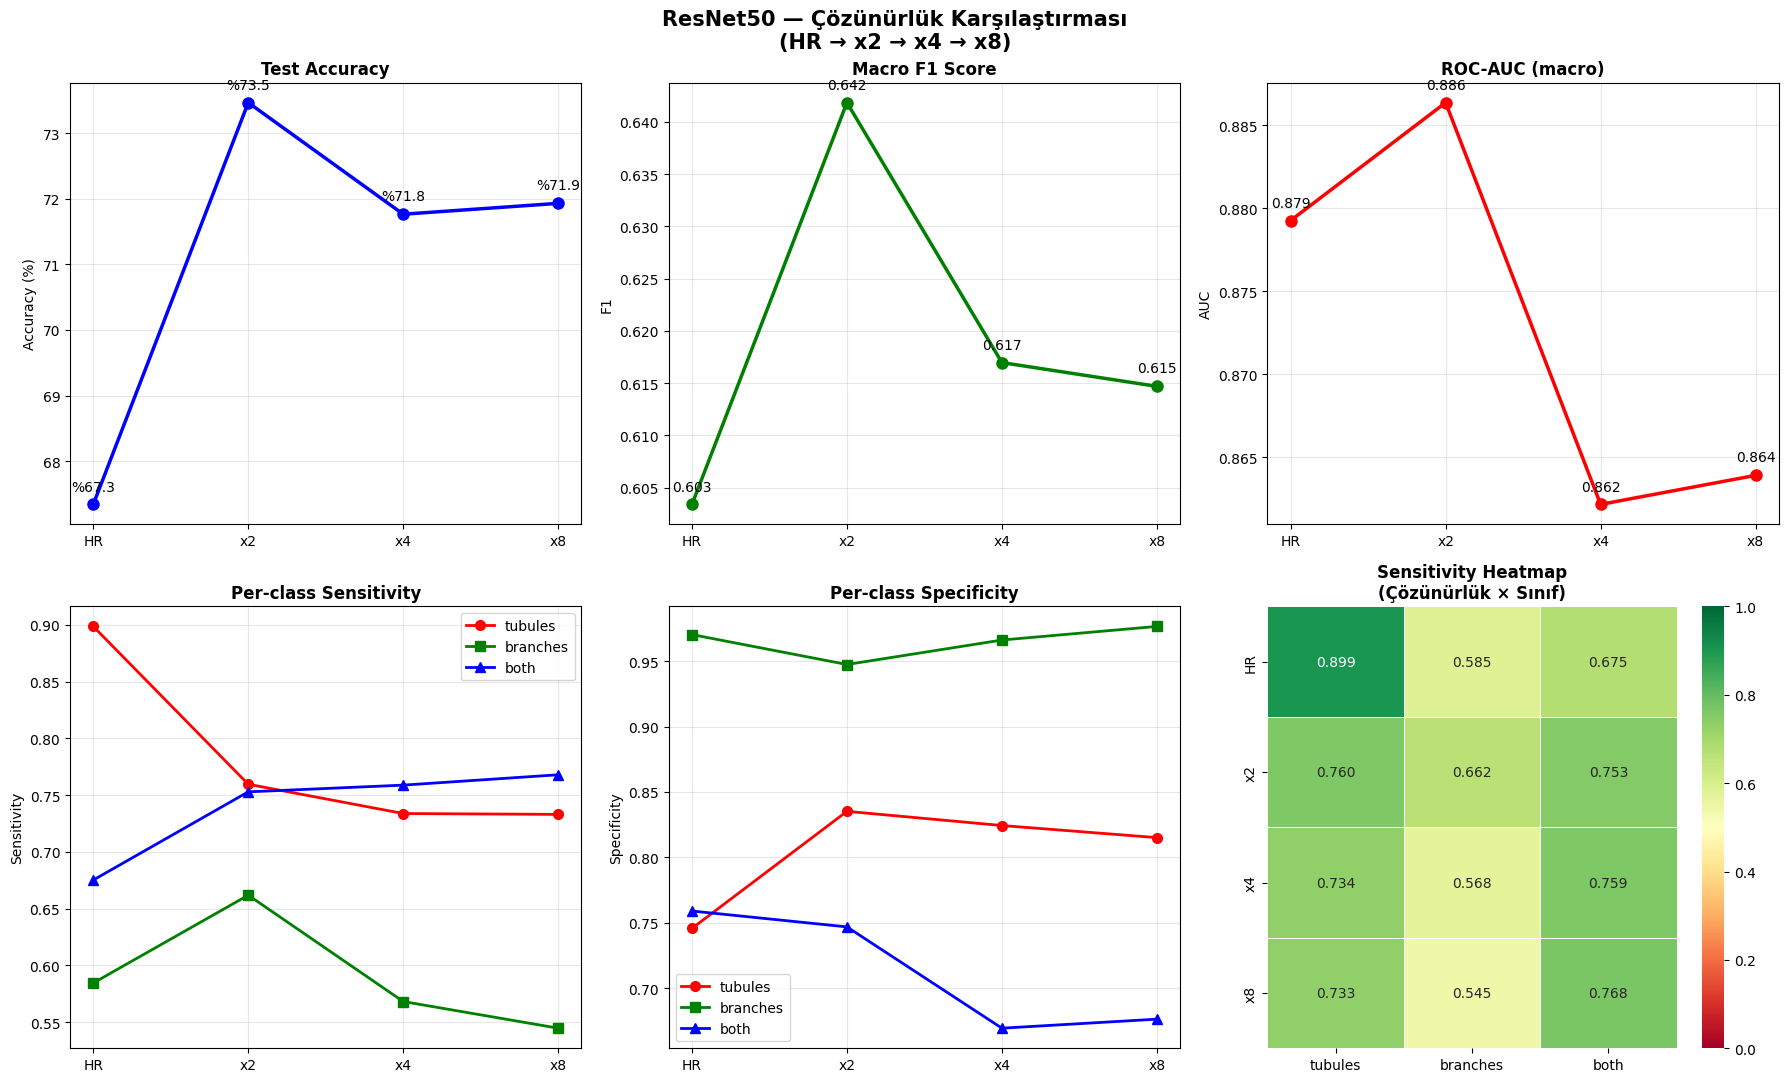

✅ Ana karşılaştırma grafiği kaydedildi!


In [5]:
# ============================================================
# HÜCRE 5: KARŞILAŞTIRMA GRAFİKLERİ
# ============================================================
cozler = COZUNURLUKLER
acc_list  = [tum_sonuclar[c]["accuracy"]   for c in cozler]
f1_list   = [tum_sonuclar[c]["f1_macro"]   for c in cozler]
auc_list  = [tum_sonuclar[c]["roc_auc"]    for c in cozler]

# Per-class sensitivity
sens_tub  = [tum_sonuclar[c]["sens_tubules"]  for c in cozler]
sens_br   = [tum_sonuclar[c]["sens_branches"] for c in cozler]
sens_both = [tum_sonuclar[c]["sens_both"]     for c in cozler]

# Per-class specificity
spec_tub  = [tum_sonuclar[c]["spec_tubules"]  for c in cozler]
spec_br   = [tum_sonuclar[c]["spec_branches"] for c in cozler]
spec_both = [tum_sonuclar[c]["spec_both"]     for c in cozler]

x = np.arange(len(cozler))

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("ResNet50 — Çözünürlük Karşılaştırması\n"
             "(HR → x2 → x4 → x8)",
             fontsize=15, fontweight='bold')

# 1. Accuracy
axes[0,0].plot(cozler, acc_list, 'b-o', ms=8, lw=2.5)
axes[0,0].set_title("Test Accuracy", fontweight='bold')
axes[0,0].set_ylabel("Accuracy (%)"); axes[0,0].grid(True, alpha=0.3)
for i, v in enumerate(acc_list):
    axes[0,0].annotate(f"%{v:.1f}", (cozler[i], v),
                       textcoords="offset points", xytext=(0,10), ha='center')

# 2. Macro F1
axes[0,1].plot(cozler, f1_list, 'g-o', ms=8, lw=2.5)
axes[0,1].set_title("Macro F1 Score", fontweight='bold')
axes[0,1].set_ylabel("F1"); axes[0,1].grid(True, alpha=0.3)
for i, v in enumerate(f1_list):
    axes[0,1].annotate(f"{v:.3f}", (cozler[i], v),
                       textcoords="offset points", xytext=(0,10), ha='center')

# 3. ROC-AUC
axes[0,2].plot(cozler, auc_list, 'r-o', ms=8, lw=2.5)
axes[0,2].set_title("ROC-AUC (macro)", fontweight='bold')
axes[0,2].set_ylabel("AUC"); axes[0,2].grid(True, alpha=0.3)
for i, v in enumerate(auc_list):
    axes[0,2].annotate(f"{v:.3f}", (cozler[i], v),
                       textcoords="offset points", xytext=(0,10), ha='center')

# 4. Per-class Sensitivity
axes[1,0].plot(cozler, sens_tub,  'r-o', ms=7, lw=2, label="tubules")
axes[1,0].plot(cozler, sens_br,   'g-s', ms=7, lw=2, label="branches")
axes[1,0].plot(cozler, sens_both, 'b-^', ms=7, lw=2, label="both")
axes[1,0].set_title("Per-class Sensitivity", fontweight='bold')
axes[1,0].set_ylabel("Sensitivity"); axes[1,0].legend(); axes[1,0].grid(True, alpha=0.3)

# 5. Per-class Specificity
axes[1,1].plot(cozler, spec_tub,  'r-o', ms=7, lw=2, label="tubules")
axes[1,1].plot(cozler, spec_br,   'g-s', ms=7, lw=2, label="branches")
axes[1,1].plot(cozler, spec_both, 'b-^', ms=7, lw=2, label="both")
axes[1,1].set_title("Per-class Specificity", fontweight='bold')
axes[1,1].set_ylabel("Specificity"); axes[1,1].legend(); axes[1,1].grid(True, alpha=0.3)

# 6. Heatmap — Sensitivity × Çözünürlük
heat_data = pd.DataFrame({
    "tubules" : sens_tub,
    "branches": sens_br,
    "both"    : sens_both,
}, index=cozler)
sns.heatmap(heat_data, annot=True, fmt='.3f', cmap='RdYlGn',
            ax=axes[1,2], vmin=0, vmax=1,
            linewidths=0.5, linecolor='white')
axes[1,2].set_title("Sensitivity Heatmap\n(Çözünürlük × Sınıf)",
                    fontweight='bold')

plt.tight_layout()
plt.savefig("cozunurluk_karsilastirma.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Ana karşılaştırma grafiği kaydedildi!")

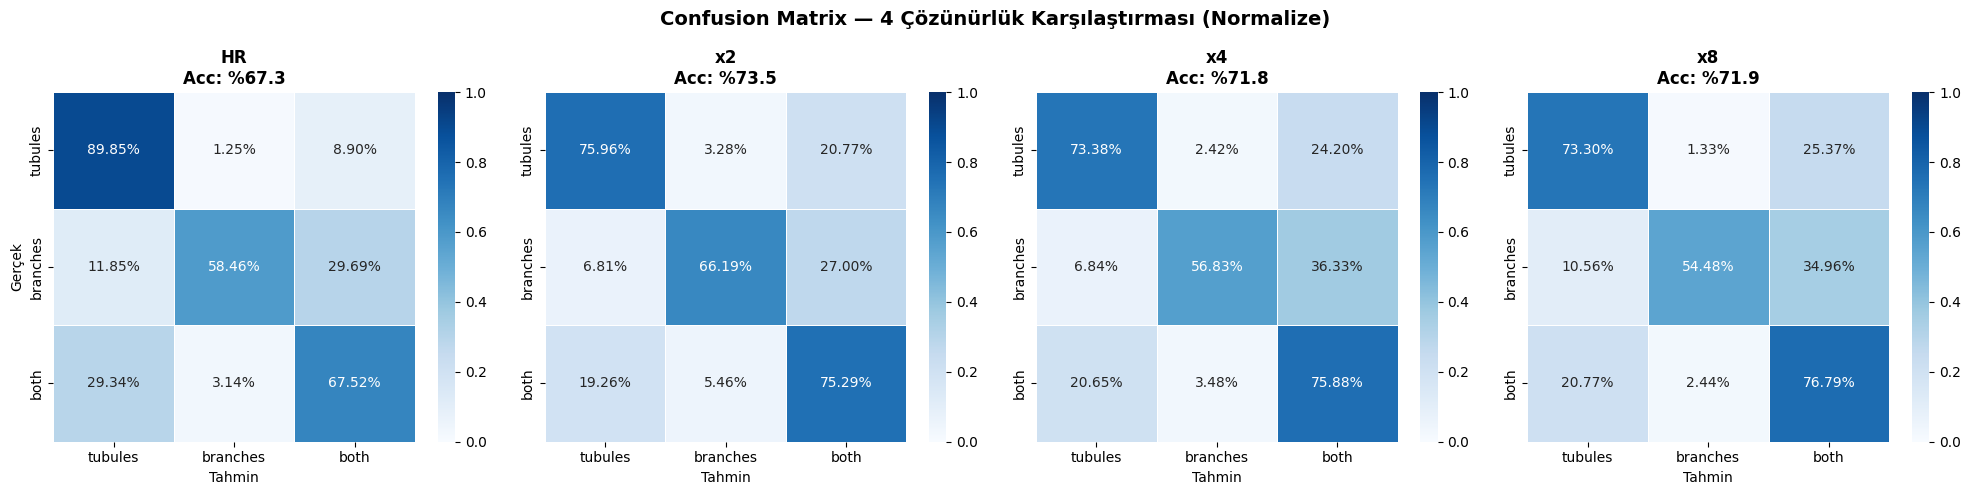

✅ 4 confusion matrix kaydedildi!


In [6]:
# ============================================================
# HÜCRE 6: 4 CONFUSION MATRIX YAN YANA
# ============================================================
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle("Confusion Matrix — 4 Çözünürlük Karşılaştırması (Normalize)",
             fontsize=14, fontweight='bold')

for i, coz in enumerate(COZUNURLUKLER):
    cm = tum_sonuclar[coz]["cm"]
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
                ax=axes[i], xticklabels=SINIFLAR, yticklabels=SINIFLAR,
                vmin=0, vmax=1, linewidths=0.5)
    axes[i].set_title(f"{coz}\nAcc: %{tum_sonuclar[coz]['accuracy']:.1f}",
                      fontweight='bold')
    axes[i].set_xlabel("Tahmin")
    if i == 0:
        axes[i].set_ylabel("Gerçek")
    else:
        axes[i].set_ylabel("")

plt.tight_layout()
plt.savefig("confusion_matrix_4coz.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ 4 confusion matrix kaydedildi!")

In [7]:
# ============================================================
# HÜCRE 7: ÖZET TABLO
# ============================================================
print("\n" + "="*75)
print(f"{'ÖZET TABLO — ResNet50 Çözünürlük Karşılaştırması':^75}")
print("="*75)
print(f"{'Çöz.':<6} {'Acc%':>6} {'F1':>7} {'AUC':>7} "
      f"{'Sens_T':>8} {'Sens_B':>8} {'Sens_Bo':>8}")
print("-"*75)
for coz in COZUNURLUKLER:
    s = tum_sonuclar[coz]
    print(f"{coz:<6} {s['accuracy']:>6.2f} {s['f1_macro']:>7.4f} "
          f"{s['roc_auc']:>7.4f} {s['sens_tubules']:>8.4f} "
          f"{s['sens_branches']:>8.4f} {s['sens_both']:>8.4f}")
print("="*75)
print("\nSens_T=tubules | Sens_B=branches | Sens_Bo=both")
print("\n✅ Notebook 05 tamamlandı!")


             ÖZET TABLO — ResNet50 Çözünürlük Karşılaştırması              
Çöz.     Acc%      F1     AUC   Sens_T   Sens_B  Sens_Bo
---------------------------------------------------------------------------
HR      67.34  0.6034  0.8793   0.8985   0.5846   0.6752
x2      73.46  0.6418  0.8864   0.7596   0.6619   0.7529
x4      71.76  0.6170  0.8622   0.7338   0.5683   0.7588
x8      71.93  0.6147  0.8639   0.7330   0.5448   0.7679

Sens_T=tubules | Sens_B=branches | Sens_Bo=both

✅ Notebook 05 tamamlandı!
